# PCMCI+ fixed-lag conditioning-depth analysis

This notebook evaluates PCMCI+ while holding the temporal model fixed at lag
one. The shared depth index `p=1,...,7` controls the maximum conditioning-set size through `max_conds_dim`, `max_conds_py`, `max_conds_px`, and
`max_conds_px_lagged`.

This makes the trajectory a conditioning-depth sensitivity analysis rather
than a varying-maximum-lag analysis. PCMCI+ may stop before reaching `p` when
conditional independence is established, so `p` is a maximum rather than an
exact condition-set size.

Configuration:

- 10 deterministic trials per `p`
- fixed `tau_min=tau_max=1`
- partial-correlation test with `pc_alpha=0.05`
- depth grid `p=1,...,7`
- scenario: `singleLag-Markovian`


In [4]:
from __future__ import annotations

import json
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

PROJECT_ROOT = next(
    (
        path
        for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (path / 'src' / 'markovianity_diagnostic').exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate the project root')

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from markovianity_diagnostic.experiments.adapters import (  # noqa: E402
    analyze_with_pcmciplus,
)
from markovianity_diagnostic.experiments.benchmark_data import (  # noqa: E402
    generate_trial_data,
)
from markovianity_diagnostic.experiments.graph_metrics import (  # noqa: E402
    recovery_metrics,
)

print(f'Project root: {PROJECT_ROOT}')


Project root: /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics


In [5]:
NUM_TRIALS = 10
SCENARIO = 'singleLag-Markovian'
MASTER_SEED = 42
N_VARS_RANGE = (18, 25)
LENGTH_RANGE = (3000, 6000)

P_VALUES = [1, 2, 3, 4, 5, 6, 7]
FIXED_LAG = 1
PC_ALPHA = 0.05
CONDITIONING_PARAMETERS = [
    'max_conds_dim',
    'max_conds_py',
    'max_conds_px',
    'max_conds_px_lagged',
]

OUTPUT_DIR = (
    PROJECT_ROOT
    / 'outputs'
    / 'simulations'
    / 'pcmci_plus_results'
    / SCENARIO
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Scenario: {SCENARIO}')
print(f'Trials per p: {NUM_TRIALS}')
print(f'Conditioning depths: {P_VALUES}')
print(f'Fixed lag: {FIXED_LAG}')
print(f'PC alpha: {PC_ALPHA}')
print(f'Output directory: {OUTPUT_DIR}')


Scenario: singleLag-Markovian
Trials per p: 10
Conditioning depths: [1, 2, 3, 4, 5, 6, 7]
Fixed lag: 1
PC alpha: 0.05
Output directory: /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics/outputs/simulations/pcmci_plus_results/singleLag-Markovian


In [6]:
all_results = []
metric_names = [
    'accuracy',
    'precision',
    'recall',
    'fpr',
    'balanced_accuracy',
    'f1',
]

for trial_id in tqdm(range(NUM_TRIALS), desc='PCMCI+ trials'):
    trial = generate_trial_data(
        SCENARIO,
        trial_id,
        seed=MASTER_SEED,
        n_vars_range=N_VARS_RANGE,
        length_range=LENGTH_RANGE,
    )
    trial_metrics = np.zeros((len(P_VALUES), len(metric_names)))
    tqdm.write(
        f'[trial {trial_id + 1}/{NUM_TRIALS}] '
        f'{trial.n_vars} variables, {trial.length} timepoints'
    )

    try:
        for depth_index, p_value in enumerate(P_VALUES):
            tqdm.write(
                f'    p={p_value} '
                f'[{depth_index + 1}/{len(P_VALUES)}] running...'
            )
            adjacency_pred = analyze_with_pcmciplus(
                trial.X.T,
                [p_value],
                pc_alpha=PC_ALPHA,
            )[p_value]
            metrics = recovery_metrics(adjacency_pred, trial.A)
            trial_metrics[depth_index] = [
                metrics[metric] for metric in metric_names
            ]
    except Exception as error:
        tqdm.write(f'Trial {trial_id} failed: {error}')
        continue

    all_results.append(trial_metrics)

all_results_array = np.asarray(all_results, dtype=float)
if all_results_array.shape[0] != NUM_TRIALS:
    raise RuntimeError(
        f'Only {all_results_array.shape[0]}/{NUM_TRIALS} trials completed'
    )

print(
    f'Completed {all_results_array.shape[0]} trials across '
    f'{len(P_VALUES)} conditioning depths'
)
print(f'Results shape: {all_results_array.shape}')


PCMCI+ trials:   0%|          | 0/10 [00:00<?, ?it/s]

[trial 1/10] 24 variables, 3860 timepoints
    p=1 [1/7] running...


PCMCI+ trials:   0%|          | 0/10 [00:05<?, ?it/s]

    p=2 [2/7] running...


PCMCI+ trials:   0%|          | 0/10 [00:13<?, ?it/s]

...

    p=6 [6/7] running...


PCMCI+ trials:  90%|█████████ | 9/10 [05:43<00:28, 28.38s/it]

    p=7 [7/7] running...


PCMCI+ trials: 100%|██████████| 10/10 [05:49<00:00, 34.97s/it]

Completed 10 trials across 7 conditioning depths
Results shape: (10, 7, 6)


In [7]:
results_rows = []
aggregated = {}

for trial_id, trial_metrics in enumerate(all_results_array):
    for depth_index, p_value in enumerate(P_VALUES):
        row = {'trial_id': trial_id, 'p': p_value}
        row.update(
            {
                metric: float(trial_metrics[depth_index, metric_index])
                for metric_index, metric in enumerate(metric_names)
            }
        )
        results_rows.append(row)

for depth_index, p_value in enumerate(P_VALUES):
    aggregated[p_value] = {}
    for metric_index, metric in enumerate(metric_names):
        values = all_results_array[:, depth_index, metric_index]
        aggregated[p_value][metric] = {
            'mean': float(np.round(np.mean(values), 4)),
            'std': float(np.round(np.std(values), 4)),
        }

results_df = pd.DataFrame(results_rows)
results_path = OUTPUT_DIR / 'pcmci_plus_results.csv'
results_df.to_csv(results_path, index=False)

aggregated_path = OUTPUT_DIR / 'pcmci_plus_aggregated.json'
aggregated_path.write_text(
    json.dumps(
        {str(p_value): aggregated[p_value] for p_value in P_VALUES},
        indent=2,
    ),
    encoding='utf-8',
)

print(results_df.groupby('p')[metric_names].mean().to_string())
print(f'Wrote {results_path}')
print(f'Wrote {aggregated_path}')


   accuracy  precision    recall       fpr  balanced_accuracy        f1
p                                                                      
1  0.617180   0.233564  0.976722  0.419789           0.778466  0.362314
2  0.898035   0.486909  0.940342  0.107271           0.916536  0.633613
3  0.962668   0.725562  0.915376  0.033769           0.940804  0.806639
4  0.979037   0.845230  0.913737  0.015581           0.949078  0.877205
5  0.983749   0.890980  0.911034  0.010148           0.950443  0.900227
6  0.985651   0.911002  0.911034  0.008068           0.951483  0.910256
7  0.986543   0.920659  0.911034  0.007100           0.951967  0.915036
Wrote /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics/outputs/simulations/pcmci_plus_results/singleLag-Markovian/pcmci_plus_results.csv
Wrote /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics/outputs/simulations/pcmc

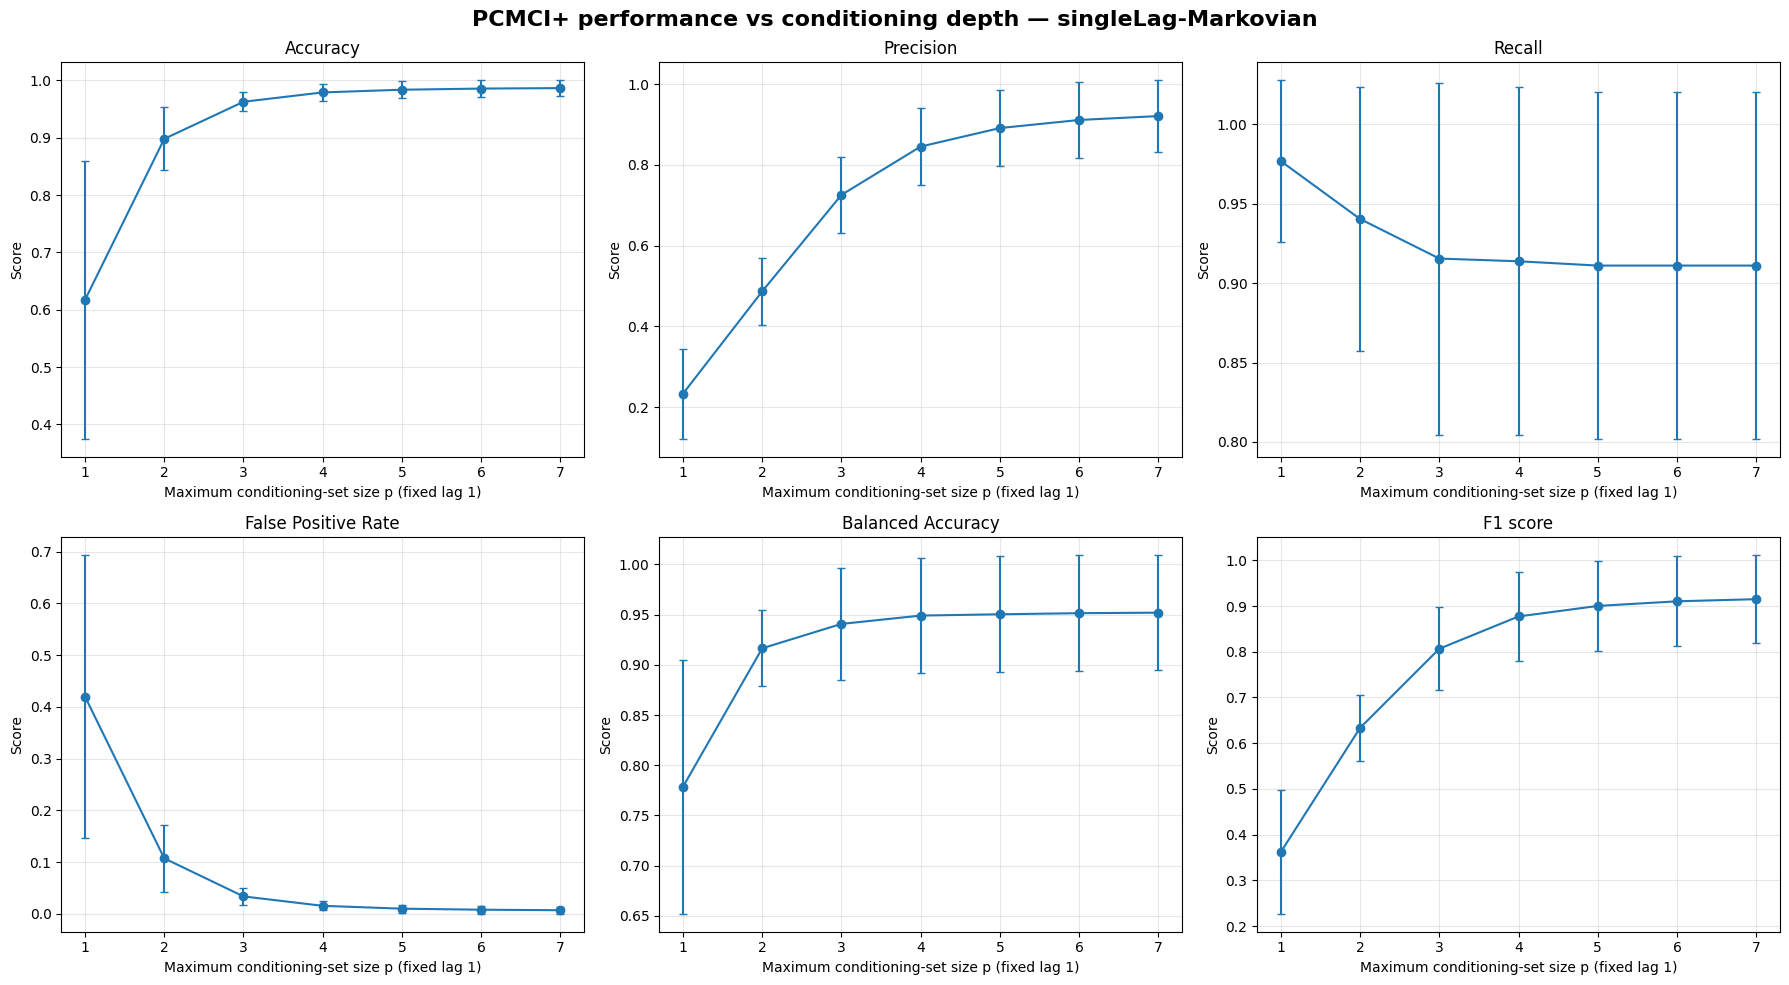

Wrote /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics/outputs/simulations/pcmci_plus_results/singleLag-Markovian/pcmci_plus_metrics.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    f'PCMCI+ performance vs conditioning depth — {SCENARIO}',
    fontsize=16,
    fontweight='bold',
)

metric_labels = {
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    'fpr': 'False Positive Rate',
    'balanced_accuracy': 'Balanced Accuracy',
    'f1': 'F1 score',
}

for axis, metric in zip(axes.ravel(), metric_names, strict=True):
    means = [aggregated[p_value][metric]['mean'] for p_value in P_VALUES]
    stds = [aggregated[p_value][metric]['std'] for p_value in P_VALUES]
    axis.plot(P_VALUES, means, marker='o')
    axis.errorbar(P_VALUES, means, yerr=stds, fmt='none', capsize=3)
    axis.set(
        xlabel='Maximum conditioning-set size p (fixed lag 1)',
        ylabel='Score',
        title=metric_labels[metric],
    )
    axis.set_xticks(P_VALUES)
    axis.grid(alpha=0.3)

fig.tight_layout()
plot_path = OUTPUT_DIR / 'pcmci_plus_metrics.png'
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Wrote {plot_path}')


In [9]:
manifest = {
    'created_at': datetime.now(timezone.utc).isoformat(),
    'analysis': 'PCMCI+ fixed-lag conditioning-depth sensitivity',
    'scenario': SCENARIO,
    'method': 'pcmciplus',
    'p_values': P_VALUES,
    'fixed_lag': FIXED_LAG,
    'pc_alpha': PC_ALPHA,
    'conditioning_parameters': CONDITIONING_PARAMETERS,
    'n_trials': NUM_TRIALS,
    'master_seed': MASTER_SEED,
    'output_paths': [
        str(results_path.relative_to(PROJECT_ROOT)),
        str(aggregated_path.relative_to(PROJECT_ROOT)),
        str(plot_path.relative_to(PROJECT_ROOT)),
    ],
}
manifest_path = OUTPUT_DIR / 'manifest.json'
manifest_path.write_text(json.dumps(manifest, indent=2), encoding='utf-8')

expected_outputs = [results_path, aggregated_path, plot_path, manifest_path]
missing_outputs = [path for path in expected_outputs if not path.exists()]
if missing_outputs:
    raise FileNotFoundError(f'Missing outputs: {missing_outputs}')
assert set(results_df['p']) == set(P_VALUES)
assert results_df.groupby('trial_id').size().eq(len(P_VALUES)).all()
print(f'Verified {len(expected_outputs)} outputs.')


Verified 4 outputs.
